# Meyer's quantum penny flip

The coin starts heads up. Q moves, Picard flips or doesn't, Q moves again, and Q wins on heads. With two Hadamards Q wins every game. The code lives in `src/quantum_penny_flip.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

from src.quantum_penny_flip import game_circuit, payoff_table, play

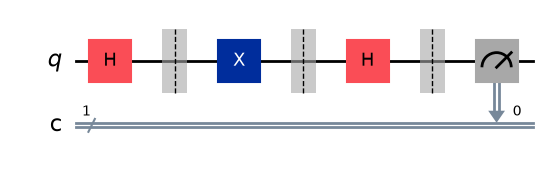

In [2]:
game_circuit("H", "X", "H").draw("mpl")

After Q's first H the coin is |+>, which sits on the x axis of the Bloch sphere. Picard's X is a rotation about that same axis, so it does nothing.

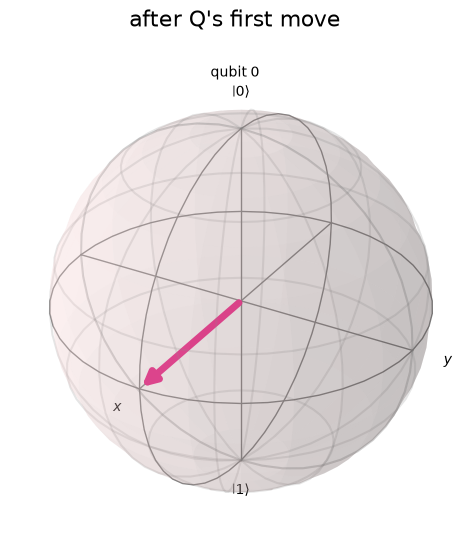

In [3]:
coin = Statevector(game_circuit("H", "I", "I", measure=False))
plot_bloch_multivector(coin, title="after Q's first move")

In [4]:
print("Q moves   Picard I   Picard X")
for (a, b), row in payoff_table().items():
    print(f"{a}, {b}      {row['I']:.2f}       {row['X']:.2f}")

Q moves   Picard I   Picard X
I, I      1.00       0.00
I, X      0.00       1.00
I, H      0.50       0.50
X, I      0.00       1.00
X, X      1.00       0.00
X, H      0.50       0.50
H, I      0.50       0.50
H, X      0.50       0.50
H, H      1.00       1.00


In [5]:
print(f"classical Q: {play(10000, 'classical', seed=0):.1%}")
print(f"quantum Q:   {play(10000, 'quantum', seed=0):.1%}")

classical Q: 50.3%
quantum Q:   100.0%
